# Single-event loss: Hurricane Michael (2018)

This notebook walks through NatCat's deterministic single-event workflow: load a
historical best track, build a parametric wind hazard footprint, apply a
vulnerability curve to an exposure portfolio, and compute a ground-up loss.
Hurricane Michael (AL142018) is a good stress test — it intensified rapidly and
made landfall near Mexico Beach, FL as a Category 5 storm.


In [1]:
import logging

logging.basicConfig(level=logging.INFO, format="%(message)s")
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from natcat import plotting

plotting.apply_style()
pd.options.display.float_format = "{:,.2f}".format


NumExpr defaulting to 10 threads.


## Best track

`load_best_track` downloads (or reuses a locally cached) NHC ATCF B-deck file and
runs it through NatCat's processing pipeline: unit conversion, hourly
interpolation, translation speed and heading.


In [2]:
from natcat.tracks import load_best_track

track = load_best_track(2018, "al", "14")
print(f"{len(track)} track records from {track['time'].min()} to {track['time'].max()}")
track.head()


2593 track records from 2018-10-06 18:00:00 to 2018-10-15 18:00:00


,time,latitude,longitude,max_wind_speed_kt,radius_max_wind_nm,min_pressure_mb,storm_type,storm_name,basin,storm_number,translation_speed_kt,heading_deg,storm_id
0,2018-10-06 18:00:00,17.80,-86.60,25.00,90.00,"1,006.00",LO,INVEST,AL,14,4.15,316.41,AL142018
1,2018-10-06 18:05:00,17.80,-86.60,25.00,90.00,"1,005.97",LO,INVEST,AL,14,4.15,316.41,AL142018
2,2018-10-06 18:10:00,17.81,-86.61,25.00,90.00,"1,005.94",LO,INVEST,AL,14,4.15,316.41,AL142018
3,2018-10-06 18:15:00,17.81,-86.61,25.00,90.00,"1,005.92",LO,INVEST,AL,14,4.15,316.41,AL142018
4,2018-10-06 18:20:00,17.82,-86.62,25.00,90.00,"1,005.89",LO,INVEST,AL,14,4.14,316.41,AL142018


In [3]:
peak = track.loc[track["max_wind_speed_kt"].idxmax()]
print(f"Peak intensity: {peak['max_wind_speed_kt']:.0f} kt at {peak['time']}")

landfall_estimate = pd.Timestamp("2018-10-10 17:30:00")
nearest_idx = (track["time"] - landfall_estimate).abs().idxmin()
print("Track record nearest NHC's estimated landfall (2018-10-10 17:30 UTC, near Mexico Beach, FL):")
track.loc[[nearest_idx]]


Peak intensity: 140 kt at 2018-10-10 17:00:00
Track record nearest NHC's estimated landfall (2018-10-10 17:30 UTC, near Mexico Beach, FL):


,time,latitude,longitude,max_wind_speed_kt,radius_max_wind_nm,min_pressure_mb,storm_type,storm_name,basin,storm_number,translation_speed_kt,heading_deg,storm_id
1146,2018-10-10 17:30:00,30.10,-85.45,137.50,12.50,919.50,HU,MICHAEL,AL,14,13.08,23.39,AL142018


Plotting the track shows the classic recurve out of the Caribbean into the Florida Panhandle.


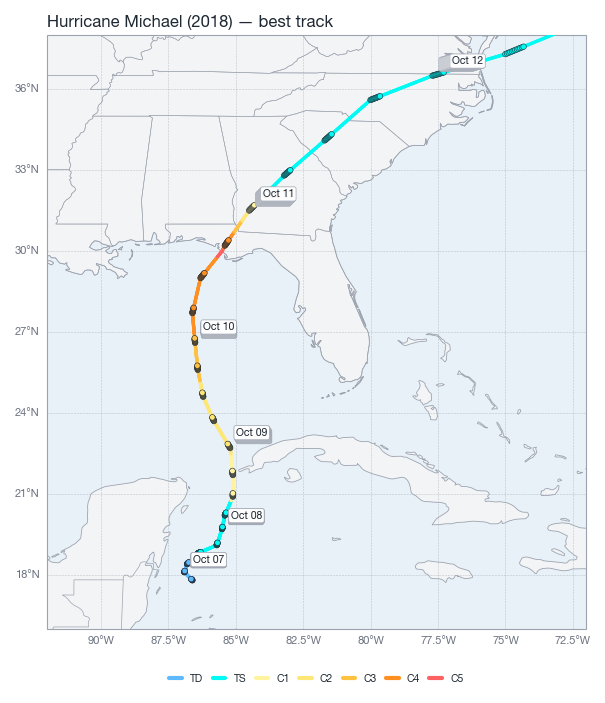

In [4]:
fig, ax = plotting.plot_track(
    track,
    extent=(-92, -72, 16, 38),
    title="Hurricane Michael (2018) — best track",
)


## Exposure

We use a LitPop-derived exposure portfolio (produced allocated GDP/population
proxy for insured value) over the Florida Panhandle landfall corridor. LitPop
data is cached locally by CLIMADA on first use; if it is unavailable in this
environment we fall back to a synthetic portfolio over the same footprint.


In [5]:
from natcat.exposure import load_litpop_exposure, synthetic_portfolio

bounds = (24.5, 32.0, -87.6, -80.0)
try:
    portfolio = load_litpop_exposure("USA", bounds=bounds)
    exposure_source = "LitPop (CLIMADA)"
except Exception as exc:
    print(f"LitPop exposure unavailable ({exc!r}); falling back to a synthetic portfolio.")
    portfolio = synthetic_portfolio(3000, bounds=bounds, seed=42)
    exposure_source = "synthetic portfolio"

print(f"Exposure source: {exposure_source}")
print(f"{len(portfolio):,} locations, total insured value ${portfolio['tiv'].sum():,.0f}")
portfolio.head()


Fetching LitPop exposure for USA via the CLIMADA data API.


Exposure source: LitPop (CLIMADA)
12,201 locations, total insured value $5,094,415,746,441


,location_id,latitude,longitude,tiv,construction
0,1,31.98,-87.56,"13,409,239.31",Masonry
1,2,31.98,-87.52,"995,530.61",Masonry
2,3,31.98,-87.48,"7,928,357.52",Frame
3,4,31.98,-87.44,"229,593.69",Frame
4,5,31.98,-87.40,"142,238.63",Masonry


## Hazard, vulnerability and ground-up loss

`TropicalCycloneHazard` computes a parametric (Holland-style) wind field along
the track; `WindVulnerability` converts local wind speed into a damage ratio
per construction type; `LossCalculator.compute` combines both with the
portfolio to produce a ground-up loss per location.


In [6]:
from natcat.hazards import TropicalCycloneHazard
from natcat.vulnerability import WindVulnerability
from natcat.loss import LossCalculator

hazard = TropicalCycloneHazard(track)
vulnerability = WindVulnerability()
calculator = LossCalculator(hazard, vulnerability)

result = calculator.compute(portfolio)
print(f"Total ground-up loss: ${calculator.total_loss:,.0f}")
result.head()


Total ground-up loss: $16,183,174,549


,location_id,latitude,longitude,tiv,construction,intensity,damage_ratio,loss
0,1,31.98,-87.56,"13,409,239.31",Masonry,7.35,0.00,0.00
1,2,31.98,-87.52,"995,530.61",Masonry,7.35,0.00,0.00
2,3,31.98,-87.48,"7,928,357.52",Frame,7.35,0.00,0.00
3,4,31.98,-87.44,"229,593.69",Frame,7.35,0.00,0.00
4,5,31.98,-87.40,"142,238.63",Masonry,7.36,0.00,0.00


The ten hardest-hit locations sit close to the eyewall track near landfall.


In [7]:
top10 = result.sort_values("loss", ascending=False).head(10)
top10[["location_id", "latitude", "longitude", "construction", "tiv", "intensity", "damage_ratio", "loss"]]


,location_id,latitude,longitude,construction,tiv,intensity,damage_ratio,loss
6247,6248,30.19,-85.65,Masonry,"3,604,098,595.41",128.93,0.74,"2,684,729,730.01"
6141,6142,30.23,-85.65,Masonry,"3,184,740,882.23",126.92,0.70,"2,217,641,549.67"
6246,6247,30.19,-85.69,Masonry,"2,738,467,050.52",129.10,0.75,"2,050,739,265.88"
6351,6352,30.15,-85.60,Masonry,"2,681,496,338.81",126.76,0.69,"1,856,403,658.35"
6248,6249,30.19,-85.60,Masonry,"1,812,507,105.34",125.39,0.66,"1,189,756,402.75"
6352,6353,30.15,-85.56,Masonry,"1,319,663,957.58",131.84,0.81,"1,063,013,583.24"
6350,6351,30.15,-85.65,Masonry,"1,269,967,614.41",132.58,0.82,"1,040,034,487.57"
6142,6143,30.23,-85.60,Masonry,"1,083,034,763.40",126.23,0.68,"734,938,719.12"
4430,4431,30.77,-85.23,Masonry,"766,768,073.82",115.86,0.38,"290,049,753.85"
6038,6039,30.27,-85.52,Masonry,"316,254,726.69",129.56,0.76,"240,069,056.27"


Loss aggregated by construction type highlights how vulnerability assumptions drive the total.


In [8]:
by_construction = (
    result.groupby("construction")[["tiv", "loss"]]
    .sum()
    .assign(damage_ratio=lambda d: d["loss"] / d["tiv"])
    .sort_values("loss", ascending=False)
)
by_construction


,tiv,loss,damage_ratio
construction,,,
Masonry,"5,088,466,506,362.29","15,919,538,931.31",0.00
Frame,"5,949,240,079.10","263,635,617.68",0.04


The footprint plot overlays modelled damage ratio, the exposure locations, and the track.


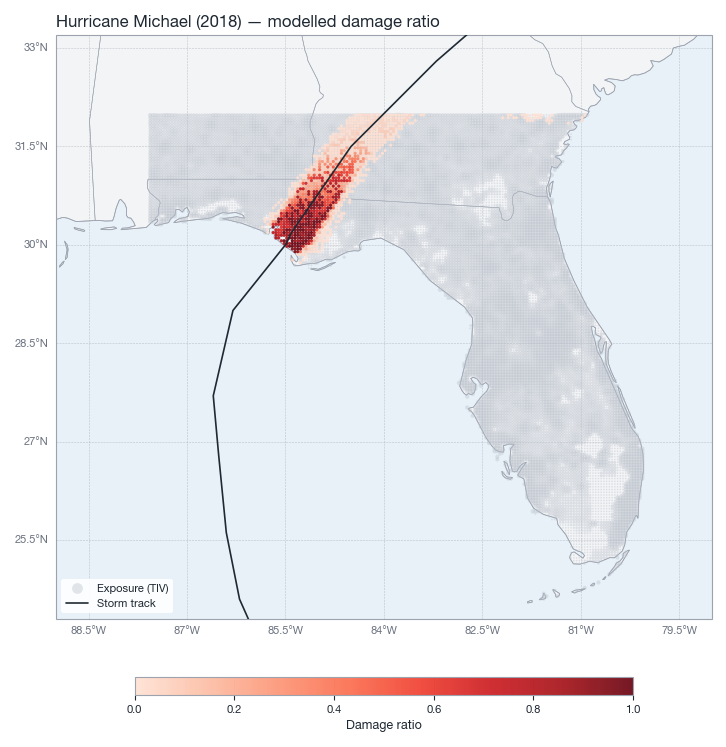

In [9]:
fig, ax = plotting.plot_footprint(
    result,
    extent=(-89, -79, 24.3, 33.2),
    portfolio=portfolio,
    track=track,
    title="Hurricane Michael (2018) — modelled damage ratio",
)


## Loss evolution over time

`compute_history` re-evaluates the hazard and loss at a series of timestamps,
which lets us trace how cumulative loss builds up as the storm approaches and
crosses the coast.


In [10]:
times = pd.date_range("2018-10-07", track["time"].max(), freq="6h")
history = calculator.compute_history(portfolio, times)
history.head()


,location_id,latitude,longitude,tiv,construction,time,intensity,damage_ratio,loss
0,1,31.98,-87.56,"13,409,239.31",Masonry,2018-10-07,1.65,0.00,0.00
1,2,31.98,-87.52,"995,530.61",Masonry,2018-10-07,1.66,0.00,0.00
2,3,31.98,-87.48,"7,928,357.52",Frame,2018-10-07,1.66,0.00,0.00
3,4,31.98,-87.44,"229,593.69",Frame,2018-10-07,1.67,0.00,0.00
4,5,31.98,-87.40,"142,238.63",Masonry,2018-10-07,1.67,0.00,0.00


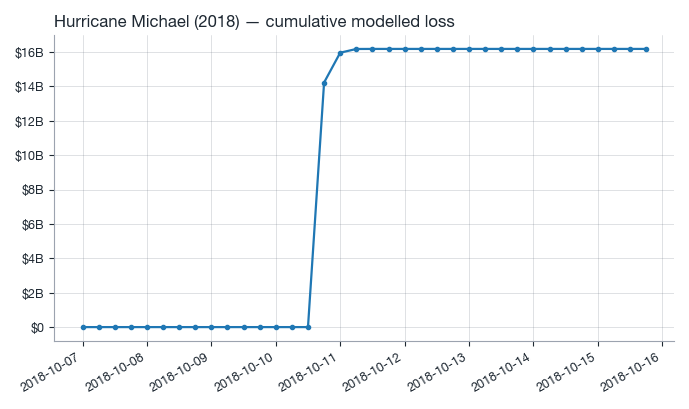

In [11]:
timeline = history.groupby("time")["loss"].sum()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(timeline.index, timeline.values, marker="o", markersize=3)
plotting.format_currency_axis(ax, "y")
ax.set_title("Hurricane Michael (2018) — cumulative modelled loss")
ax.set_xlabel("")
fig.autofmt_xdate()


## Damage evolution animation

`animate_footprint` renders the same time series as a GIF, which is often the
clearest way to communicate how a footprint develops to non-technical
stakeholders.


/opt/homebrew/Caskroom/miniforge/base/envs/NatCat/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1677: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  result = super().scatter(*args, **kwargs)
Animation.save using <class 'matplotlib.animation.PillowWriter'>


Disabling savefig.bbox = 'tight', as it may cause frame size to vary, which is inappropriate for animation.


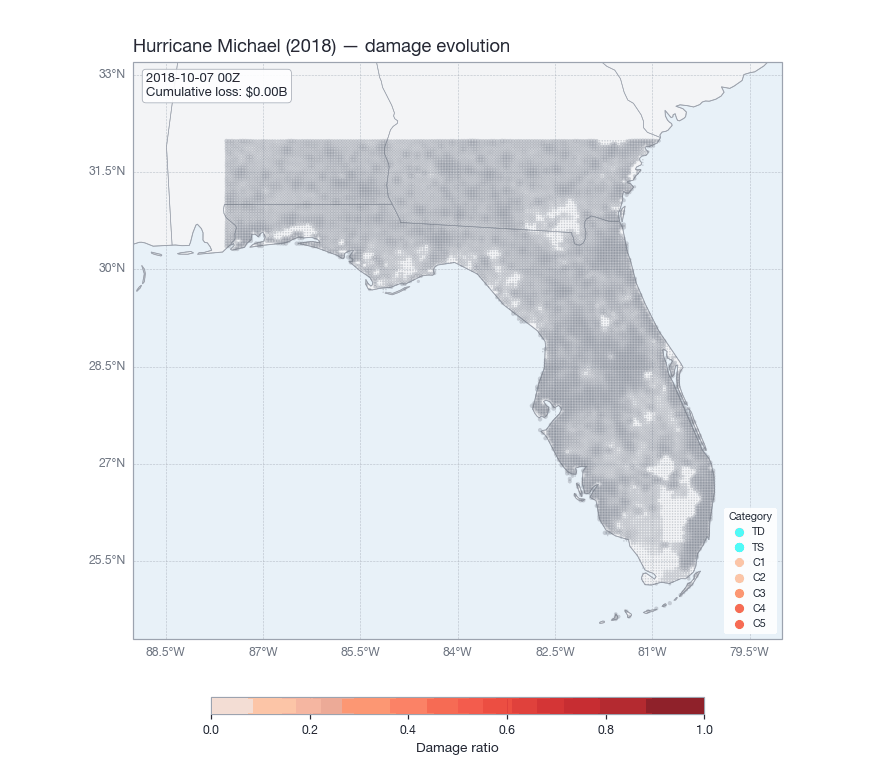

In [12]:
from pathlib import Path
from IPython.display import Image

Path("_output").mkdir(exist_ok=True)

gif_path = plotting.animate_footprint(
    history,
    track=track,
    portfolio=portfolio,
    extent=(-89, -79, 24.3, 33.2),
    path="_output/michael_damage_evolution.gif",
    title="Hurricane Michael (2018) — damage evolution",
)
Image(filename=str(gif_path))


## What to try next

- Vary `TropicalCycloneHazard(track, decay_exponent=...)` to see how quickly wind
  speed falls off with distance from the eye, and how that reshapes the
  footprint.
- Change `asymmetry_factor` to control how much stronger the right-front
  quadrant is relative to the left-rear quadrant.
- Pass custom `params` to `WindVulnerability` to model a portfolio with
  different construction-type damage curves (e.g. a retrofitted masonry
  stock), and compare the resulting total loss and loss-by-construction
  breakdown.
